In [16]:
from processing import prepare_data
from processing import build_preprocessor
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [4]:
train_path = r"C:\kaggle_ev_purchase\data\raw\train.csv"
X_dev, X_holdout, y_dev, y_holdout = prepare_data(train_path)

print("Desenvolvimento:", X_dev.shape)
print("Reserva:", X_holdout.shape)

Desenvolvimento: (635231, 13)
Reserva: (33434, 13)


In [5]:
xgb_pipeline = Pipeline([
    ("preprocessor", build_preprocessor(X_dev)),
    ("model", XGBClassifier(random_state=42, n_jobs=1)),
])

In [6]:
lgbm_pipeline = Pipeline([
    ("preprocessor", build_preprocessor(X_dev)),
    ("model", LGBMClassifier(random_state=42, n_jobs=1)),
])

In [12]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

params_xgb = {
    "model__n_estimators": [2000],
    "model__max_depth": [2, 3, 4, 6],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__min_child_weight": [1, 5, 15],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__reg_lambda": [1, 5, 15],
}

params_lgbm = {
    "model__n_estimators": [2000],
    "model__num_leaves": [7, 15],
    "model__max_depth": [2, 3, 4],
    "model__learning_rate": [0.05, 0.01, 0.1],
    "model__min_child_samples": [1, 5, 15],
    "model__subsample": [0.8, 1.0],
    "model__subsample_freq": [0, 1],
    "model__colsample_bytree": [0.8, 1.0],
    "model__reg_lambda": [1, 5, 15],
}

In [13]:
search_xgb = RandomizedSearchCV(
    xgb_pipeline,
    params_xgb,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=2,
    refit=True,
    error_score="raise",
    verbose=1,
)

search_lgbm = RandomizedSearchCV(
    lgbm_pipeline,
    params_lgbm,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=2,
    refit=True,
    error_score="raise",
    verbose=1,
)

search_xgb.fit(X_dev, y_dev)
search_lgbm.fit(X_dev, y_dev)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
[LightGBM] [Info] Number of positive: 110940, number of negative: 524291
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.111141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 636
[LightGBM] [Info] Number of data points in the train set: 635231, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174645 -> initscore=-1.553057
[LightGBM] [Info] Start training from score -1.553057
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.05, 0.01, ...], 'model__max_depth': [2, 3, ...], 'model__min_child_samples': [1, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable

In [14]:
import pandas as pd
from sklearn.metrics import roc_auc_score, precision_score, recall_score

y_proba_xgb = search_xgb.predict_proba(X_holdout)[:, 1]
y_proba_lgbm = search_lgbm.predict_proba(X_holdout)[:, 1]

results = []

for name, search, probabilities in [
    ("XGBoost", search_xgb, y_proba_xgb),
    ("LightGBM", search_lgbm, y_proba_lgbm),
]:
    predictions = (probabilities >= 0.5).astype(int)

    results.append({
        "Modelo": name,
        "AUC média da busca": search.best_score_,
        "AUC holdout": roc_auc_score(y_holdout, probabilities),
        "Precision holdout": precision_score(
            y_holdout, predictions, zero_division=0
        ),
        "Recall holdout": recall_score(
            y_holdout, predictions, zero_division=0
        ),
    })

display(pd.DataFrame(results).round(5))

,Modelo,AUC média da busca,AUC holdout,Precision holdout,Recall holdout
0,XGBoost,0.94203,0.94245,0.72478,0.67066
1,LightGBM,0.94208,0.94251,0.72462,0.67101


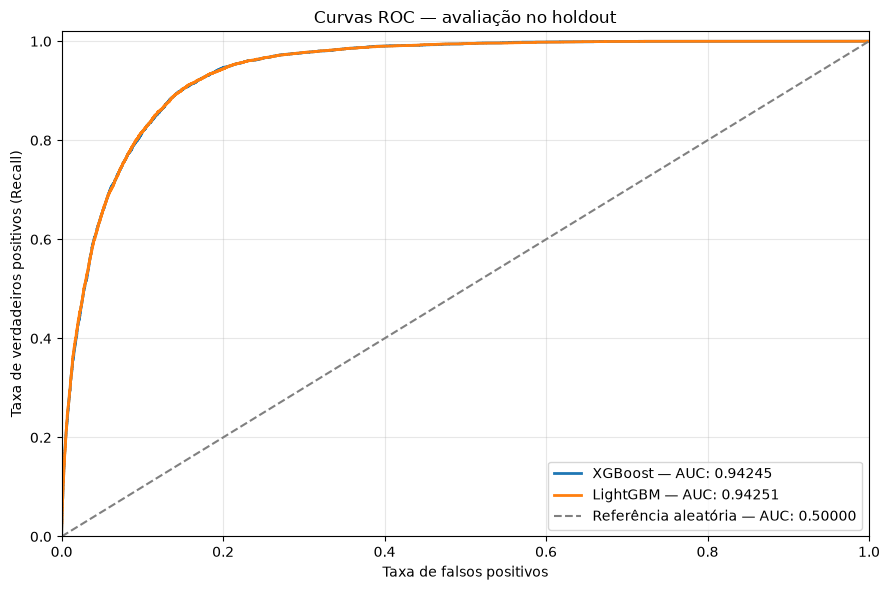

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))

for name, probabilities in [
    ("XGBoost", y_proba_xgb),
    ("LightGBM", y_proba_lgbm),
]:
    fpr, tpr, thresholds = roc_curve(y_holdout, probabilities)
    auc_score = roc_auc_score(y_holdout, probabilities)

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} — AUC: {auc_score:.5f}",
    )

ax.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color="gray",
    label="Referência aleatória — AUC: 0.50000",
)

ax.set(
    title="Curvas ROC — avaliação no holdout",
    xlabel="Taxa de falsos positivos",
    ylabel="Taxa de verdadeiros positivos (Recall)",
    xlim=(0, 1),
    ylim=(0, 1.02),
)

ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()